# simple_perceptron

This notebook shows a minimal, reproducible example for some of the features of the simple morphological perceptrons implementation.  
Two perceptrons will be created, (dilation and erosion).
This notebook will not show how multiple solvers can be used to train the perceptrons, as an explanation is available in l-DEP and DEP notebooks already.

both perceptrons will be trained on a toy binary dataset (scikit-learn's "two moons" with noise) and their decision boundary will be displayed with matplotlib.

## 1. Train the morphological perceptrons

Let us start by importing the necessary modules:

In [1]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from sklearn_morpho.classifiers.simple_perceptron import MorphoPerceptron as MP

We then create a dataset, optionally generated with a set seed for reproducibility.

Here, the points' labels are transformed from $\{0, 1\}$ to $\{red, blue\}$ to show how the estimator supports it.  
This will also be useful later, when displaying the results, but it is obviously not mandatory.

In [2]:
random_state = np.random.RandomState(42)

X, y = make_moons(n_samples=1000, noise=0.2, random_state=random_state)
y = np.array(['red', 'blue'])[y]

A perceptron can then be created, then trained on this dataset.  
Here, the parameters are all left to the default values, except for:

- `random_state` for reproducibility once again
- `verbose` to display useful information

The other parameters are described in `help(DEP)` and will not be covered here.

The `kind` mandatory parameter must be either `'min'` or `'max'`, or preferably of the enum type `Kind` defined in the `utils` subpackage.
This defines the function that is used for the decision function, respectively

$$ \max(w+x) \text{or} \min(w+x) $$

Finally, the dataset is split in two parts using `train_test_split`: one for training and another for testing, to avoid bias.

An important note is that simple perceptrons work best if the class with the positive label has generally higher coordinate values than that of the other class.
If that is not the case, the optional `inversion_method` initialization parameter supports heuristics for internally swapping which class corresponds to a positive label.
The default heuristic uses the centroids of each class, but that might not be suitable for all datasets which is why other heuristics, or user-defined ones, may be set instead.

In [3]:
perceptron_max = MP(kind='max', verbose=1, random_state=random_state)
perceptron_min = MP(kind='min', verbose=1, random_state=random_state)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=random_state
)

perceptron_max.fit(X_train, y_train)
perceptron_min.fit(X_train, y_train)

Starting fitting with DCCP (with manual linearization)
Epoch 1, training cost: 31.74479738, validation: 15.70452512
Epoch 2, training cost: 31.74479738, validation: 15.70452512
Epoch 3, training cost: 31.74479738, validation: 15.70452512
Epoch 4, training cost: 31.74479738, validation: 15.70452512
Epoch 5, training cost: 31.74479738, validation: 15.70452512
Epoch 6, training cost: 31.74479738, validation: 15.70452512
DCCP done in 6 epochs, final validation cost is 15.70452512 in 0.06s
Starting fitting with DCCP (with manual linearization)
Epoch 1, training cost: 77.88012019, validation: 18.48437222
Epoch 2, training cost: 36.82237084, validation: 13.20578549
Epoch 3, training cost: 34.64502916, validation: 12.77608063
Epoch 4, training cost: 34.64502916, validation: 12.77608063
Epoch 5, training cost: 34.64502916, validation: 12.77608063
Epoch 6, training cost: 34.64502916, validation: 12.77608063
Epoch 7, training cost: 34.64502916, validation: 12.77608063
Epoch 8, training cost: 34.6

,kind,'min'
,verbose,1
,random_state,RandomState(M...0x7F938BB5B240
,margin,0.0
,penalty,0.0
,validation_ratio,0.3
,weighting_method,None
,stopping_methods,None
,inversion_method,None
,solver,None
Name,Type,Value


The estimators are now trained, it is now possible to display the results of the training.

## 2. Display the results

Let us once again import useful modules to display the results and calculate the F1 score.

Scikit-learn implements the `DecisionBoundaryDisplay` function, which will be used here to display the decision boundary.

In [4]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import f1_score

We can now calculate the F1 score:

Since the labels are not numbered here (they are color names), a `pos_label` is explicitly defined.

In [5]:
score_test_max = f1_score(
    y_test, perceptron_max.predict(X_test), pos_label=np.unique(y)[1]
)
score_test_min = f1_score(
    y_test, perceptron_min.predict(X_test), pos_label=np.unique(y)[1]
)

Now for the results:

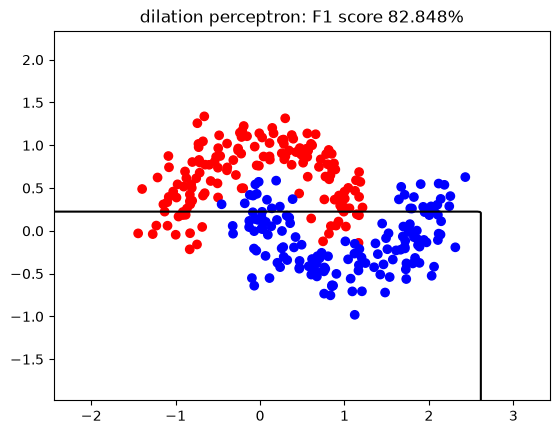

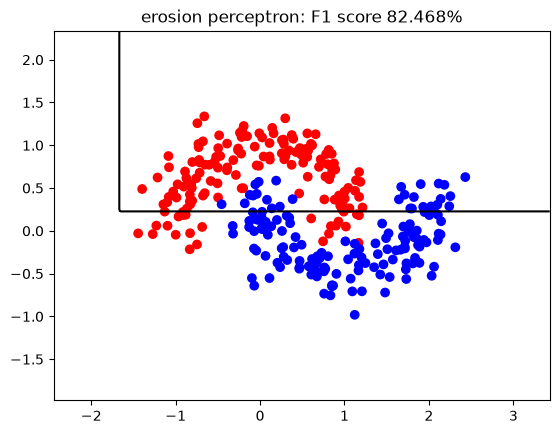

In [6]:
for name, estimator, score in (
    ('dilation perceptron', perceptron_max, score_test_max),
    ('erosion perceptron', perceptron_min, score_test_min),
):
    # draw the decision boundary
    disp = DecisionBoundaryDisplay.from_estimator(
        estimator,
        X_test,
        response_method='decision_function',
        grid_resolution=200,
        plot_method='contour',
        levels=[0],
        colors='black',
    )

    # add the points
    ax = disp.ax_
    ax.scatter(*X_test.T, color=y_test)
    ax.title.set_text(f'{name}: F1 score {score * 100:.3f}%')
    plt.show()